In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from umap import UMAP

/usr/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Загрузка данных
digits = load_digits()
X, y = digits.data, digits.target
X_scaled = StandardScaler().fit_transform(X)

In [4]:
# Визуализация (PCA/t-SNE/UMAP)
def plot_embedding(embedding, title):
    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(embedding[:, 0], embedding[:, 1], c=y, cmap='Spectral', s=10, alpha=0.8)
    plt.colorbar(scatter)
    plt.title(title)
    plt.show()

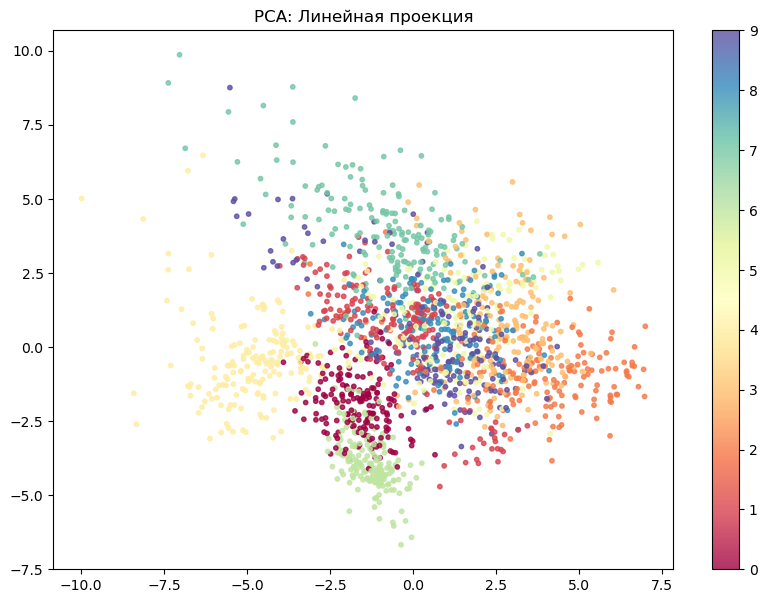

In [5]:
# PCA (Линейный метод)
# Используем не только для визуализации, но и если хотим жать данные,
# сохранив максимум "пользы" из признаков.
# Для digits первые 2 компонента обычно объясняют лишь часть вариативности,
# поэтому на графике классы цифр будут сильно перекрываться.
# Когда использовать: Если нужно убрать шум
# или подготовить данные для другой модели (например, логистической регрессии),
# чтобы она работала быстрее.
# Практичность: Высокая для препроцессинга, низкая для качественной визуализации.
pca_2d = PCA(n_components=2).fit_transform(X_scaled)
plot_embedding(pca_2d, "PCA: Линейная проекция")

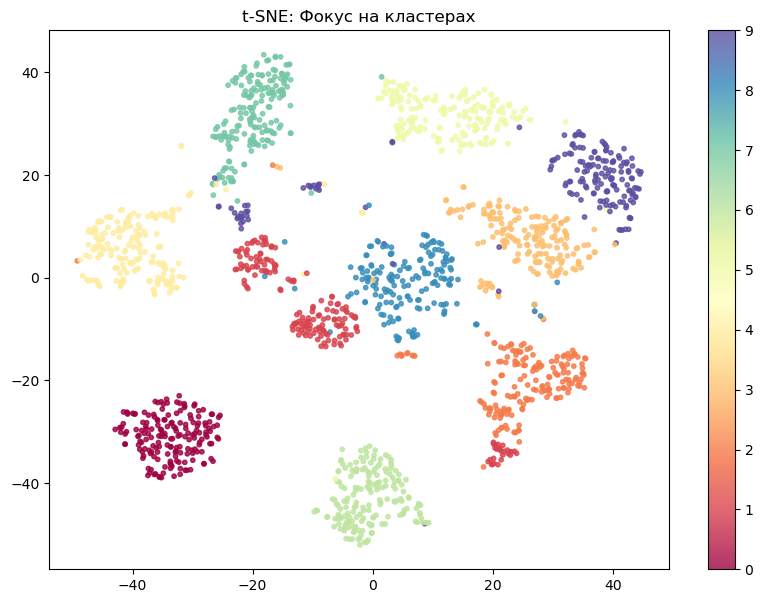

In [6]:
# t-SNE (Сохраняет локальные структуры)
# Нелинейный алгоритм, который пытается сохранить локальные расстояния:
# близкие точки в 64-мерном пространстве должны остаться близкими на плоскости.
# Благодаря методу можем понять внутреннюю структуру данных.
# t-SNE отлично разделяет цифры на четкие кластеры.
# Сразу видим, что «нолики» живут в одной куче, а «единицы» — в другой.
# Когда используем: только для визуализации и поиска аномалий.
# t-SNE не сохраняет глобальную структуру
# (расстояние между кластером "1" и "7" может не иметь смысла).
tsne_2d = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto').fit_transform(X_scaled)
plot_embedding(tsne_2d, "t-SNE: Фокус на кластерах")

/usr/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


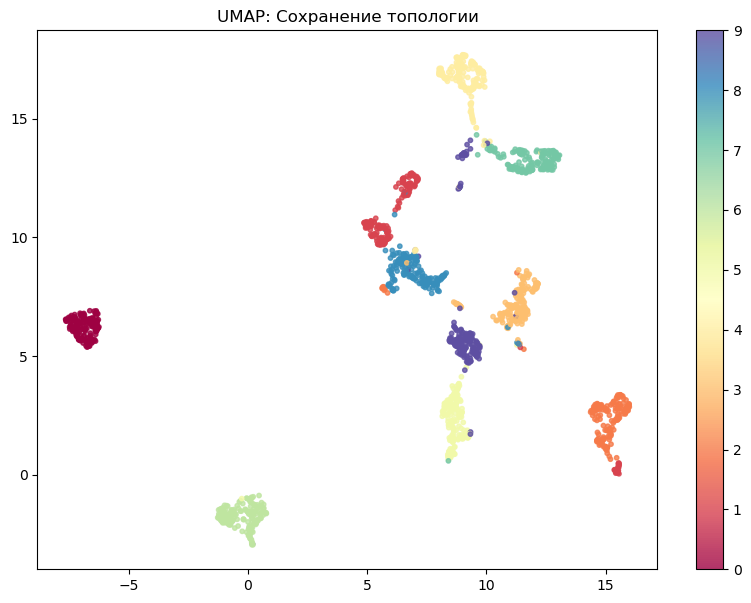

In [7]:
# UMAP (Баланс локальной и глобальной структуры)
# В отличие от t-SNE, UMAP лучше сохраняет не только локальные связи,
# но и глобальную структуру (соотношение кластеров между собой).
# Обычно он дает более «сбитые» и чистые группы.
# Используем, когда нужен баланс между скоростью и качеством.
# UMAP работает значительно быстрее, чем t-SNE.
# В принципе, его можно использовать и для визуализации,
# и как шаг Feature Engineering перед кластеризацией.
umap_2d = UMAP(n_components=2, random_state=42).fit_transform(X_scaled)
plot_embedding(umap_2d, "UMAP: Сохранение топологии")

In [8]:
# PCA для ускорения и качества обучения

# Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Вариант 1: Обучение на всех признаках (64 фичи)
model_full = LogisticRegression(max_iter=1000)
model_full.fit(X_train, y_train)
acc_full = accuracy_score(y_test, model_full.predict(X_test))

# Вариант 2: PCA
pca_transformer = PCA(n_components=40)
X_train_pca = pca_transformer.fit_transform(X_train)
X_test_pca = pca_transformer.transform(X_test)

model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, model_pca.predict(X_test_pca))

# Сравнение результатов
print(f"Результаты классификации:")
print(f"Без PCA (64 признака): {acc_full:.4f}")
print(f"С PCA ({X_train_pca.shape[1]} признаков): {acc_pca:.4f}")
print(f"Сжатие данных в {X_train.shape[1] / X_train_pca.shape[1]:.1f} раза")

Результаты классификации:
Без PCA (64 признака): 0.9704
С PCA (40 признаков): 0.9704
Сжатие данных в 1.6 раза


Обучим модель (например, лог. регрессии) для датасета fetch_olivetti_faces без использования PCA и с использованием PCA. Сравним точности предсказания.



In [5]:
from sklearn.datasets import fetch_olivetti_faces

In [10]:
data = fetch_olivetti_faces()
X, y = data.data, data.target

# Масштабирование
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделение на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /home/aukvary/scikit_learn_data


/usr/lib/python3.14/site-packages/sklearn/datasets/_base.py:1519: UserWarning: Retry downloading from url: https://ndownloader.figshare.com/files/5976027
  warnings.warn(f"Retry downloading from url: {remote.url}")


In [11]:
# Вариант 1: Обучение на всех признаках (4096 фичи)
model_full = LogisticRegression(max_iter=1000)
model_full.fit(X_train, y_train)
acc_full = accuracy_score(y_test, model_full.predict(X_test))

# Вариант 2: PCA (не будем подбирать через цикл число признаков для сохранения,
# попросим модель сделать это самостоятельно через парам-р svd_solver='covariance_eigh')
pca_transformer = PCA(svd_solver='covariance_eigh')
X_train_pca = pca_transformer.fit_transform(X_train)
X_test_pca = pca_transformer.transform(X_test)

model_pca = LogisticRegression(max_iter=1000)
model_pca.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, model_pca.predict(X_test_pca))

# Сравнение результатов
print(f"Результаты классификации:")
print(f"Без PCA (4096 признака): {acc_full:.4f}")
print(f"С PCA ({X_train_pca.shape[1]} признаков): {acc_pca:.4f}")
print(f"Сжатие данных в {X_train.shape[1] / X_train_pca.shape[1]:.1f} раза")

Результаты классификации:
Без PCA (4096 признака): 0.9625
С PCA (320 признаков): 0.9750
Сжатие данных в 12.8 раза


# Кластеризация

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [13]:
def lloyds_algorithm(data, k, metric='euclidean', max_iters=100):
    # Случайная инициализация центроидов
    np.random.seed(42)
    centroids = data[np.random.choice(data.shape[0], k, replace=False)]

    for _ in range(max_iters):
        # Расчет расстояний
        if metric == 'euclidean':
            # L2: корень из суммы квадратов разностей
            dist = np.linalg.norm(data[:, np.newaxis] - centroids, axis=2)
        elif metric == 'manhattan':
            # L1: сумма абсолютных разностей
            dist = np.abs(data[:, np.newaxis] - centroids).sum(axis=2)

        # Определение ближайшего центроида
        labels = np.argmin(dist, axis=1)

        # Пересчет центроидов как среднее арифметическое точек кластера
        new_centroids = np.array([data[labels == i].mean(axis=0) for i in range(k)])

        # Проверка на сходимость
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids

    return centroids, labels

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Генерация сферического датасета
X_spherical, y_spherical = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=0.6,
    random_state=42
)

# Генерация вытянутого датасета (распределение Лапласа)
np.random.seed(42)
# Первый кластер вытянут по горизонтали (scale [2, 0.5])
c1 = np.random.laplace(loc=[0, 0], scale=[2, 0.5], size=(150, 2))
# Второй кластер вытянут по вертикали (scale [0.5, 2])
c2 = np.random.laplace(loc=[8, 8], scale=[0.5, 2], size=(150, 2))
X_axial = np.vstack([c1, c2])
y_axial = np.hstack([np.zeros(150), np.ones(150)])

In [15]:
# Задача, визуализировать оба датасета какой метод выберите?:

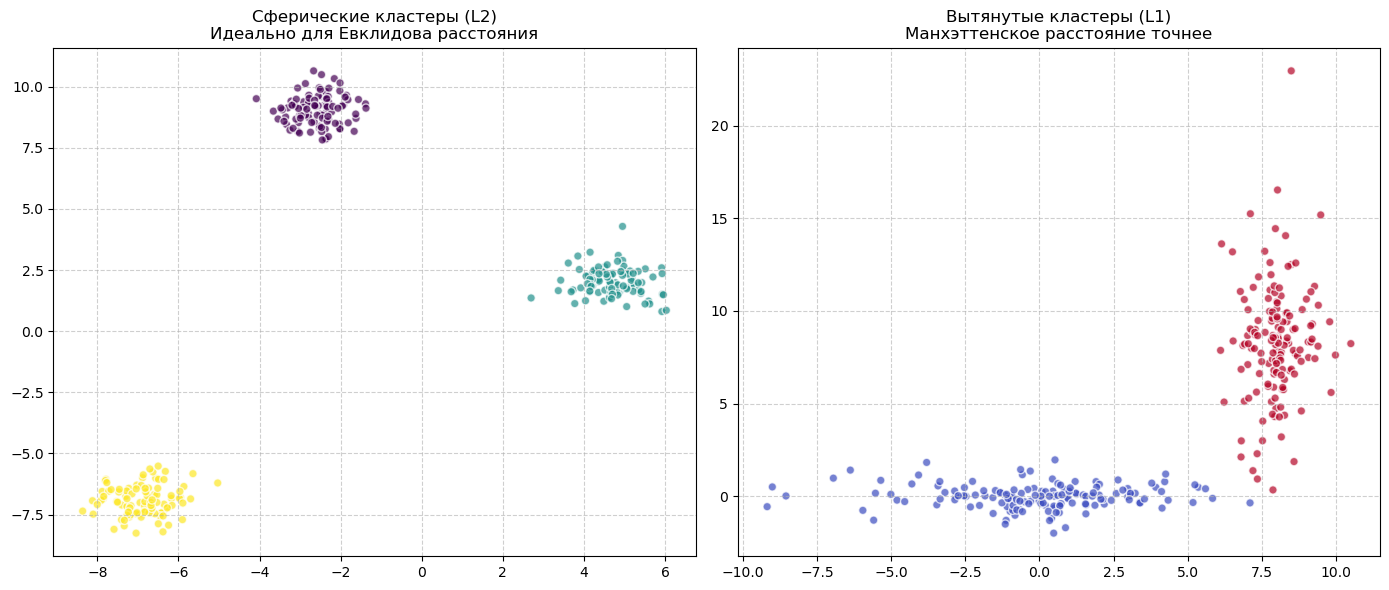

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Отрисовка сферических данных
ax1.scatter(X_spherical[:, 0], X_spherical[:, 1], c=y_spherical, cmap='viridis', alpha=0.7, edgecolors='w')
ax1.set_title("Сферические кластеры (L2)\nИдеально для Евклидова расстояния", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)

# Отрисовка осевых данных
ax2.scatter(X_axial[:, 0], X_axial[:, 1], c=y_axial, cmap='coolwarm', alpha=0.7, edgecolors='w')
ax2.set_title("Вытянутые кластеры (L1)\nМанхэттенское расстояние точнее", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

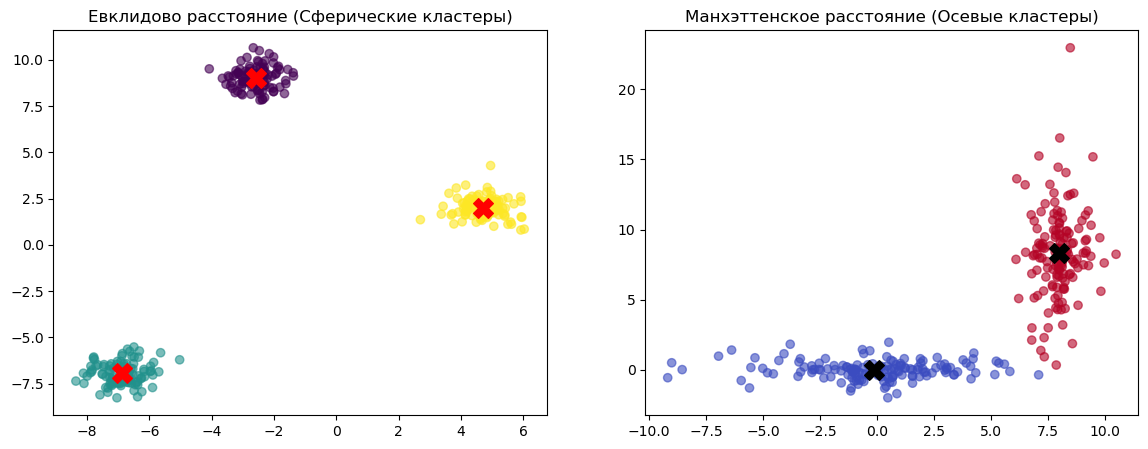

In [17]:
# На сферах
cent_s, lab_s = lloyds_algorithm(X_spherical, k=3, metric='euclidean')

# На вытянутых данных (сравнение)
cent_a_e, lab_a_e = lloyds_algorithm(X_axial, k=2, metric='euclidean')
cent_a_m, lab_a_m = lloyds_algorithm(X_axial, k=2, metric='manhattan')

# Визуализация
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(X_spherical[:, 0], X_spherical[:, 1], c=lab_s, cmap='viridis', alpha=0.6)
ax[0].scatter(cent_s[:, 0], cent_s[:, 1], c='red', marker='X', s=200, label='Центроиды')
ax[0].set_title("Евклидово расстояние (Сферические кластеры)")

ax[1].scatter(X_axial[:, 0], X_axial[:, 1], c=lab_a_m, cmap='coolwarm', alpha=0.6)
ax[1].scatter(cent_a_m[:, 0], cent_a_m[:, 1], c='black', marker='X', s=200, label='L1 Центроиды')
ax[1].set_title("Манхэттенское расстояние (Осевые кластеры)")

plt.show()

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

In [19]:
# Генерируем датасет "Две луны"
X, y = make_moons(n_samples=300, noise=0.05, random_state=42)

# Масштабирование данных (Важно для DBSCAN, так как eps общий для всех осей)
X_scaled = StandardScaler().fit_transform(X)

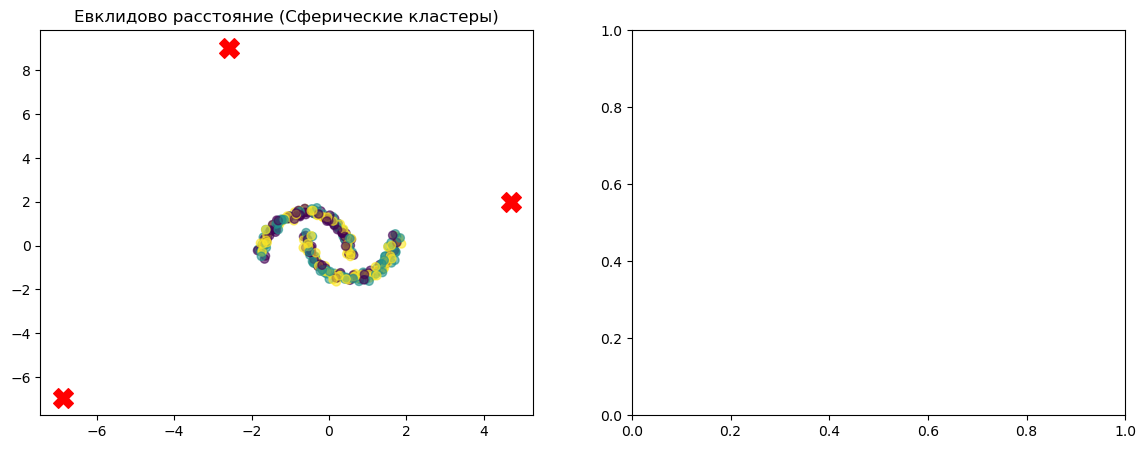

In [20]:
# На вытянутых данных (сравнение)
cent_a_e, lab_a_e = lloyds_algorithm(X_scaled, k=2, metric='euclidean')
# Визуализация
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].scatter(X_scaled[:, 0], X_scaled[:, 1], c=lab_s, cmap='viridis', alpha=0.6)
ax[0].scatter(cent_s[:, 0], cent_s[:, 1], c='red', marker='X', s=200, label='Центроиды')
ax[0].set_title("Евклидово расстояние (Сферические кластеры)")

plt.show()

In [21]:
# Настройка и запуск DBSCAN
# eps: радиус окрестности (самый важный параметр)
# min_samples: сколько точек должно быть в радиусе eps, чтобы считать точку ядровой
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

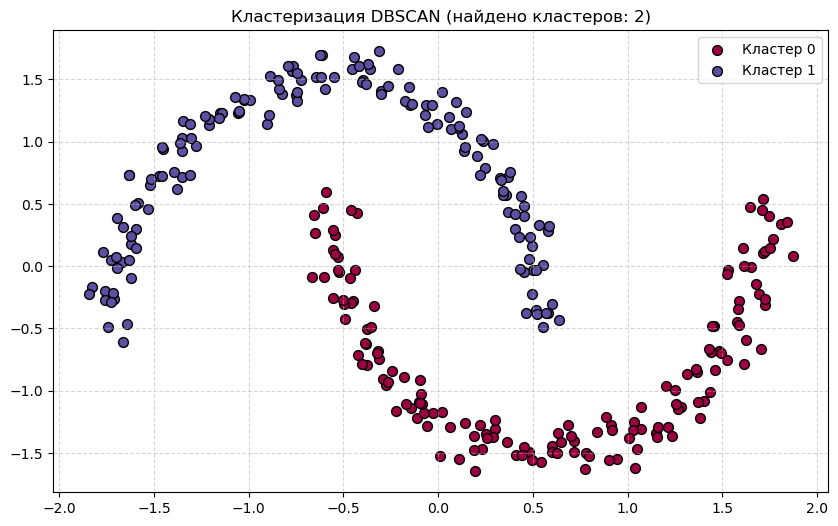

In [22]:
# Визуализация
plt.figure(figsize=(10, 6))

# Выделяем шум (точки с меткой -1) отдельно
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Черный цвет для шума
        col = [0, 0, 0, 1]
        label_name = 'Шум'
    else:
        label_name = f'Кластер {k}'

    class_member_mask = (labels == k)
    xy = X_scaled[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], edgecolors='k', s=50, label=label_name)

plt.title(f'Кластеризация DBSCAN (найдено кластеров: {len(unique_labels) - (1 if -1 in labels else 0)})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [2]:
# Задача: Мастштабировать данные, визуализировать в 2D датасет удобным
# для Вас методом
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [44]:
# Загрузка данных
wine = load_wine()
X = wine.data
y = wine.target # Реальные метки (только для сравнения)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

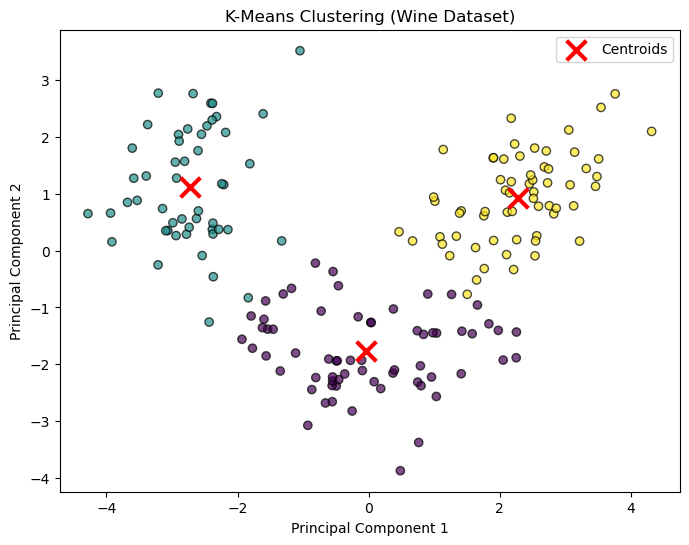

In [46]:
# Используя k-means при n_clusters=(определить по визуализации) обучить модель
# и визуализировать предсказанные кластеры (и центроиды)
# поэкспериментируйте с параметрами
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

centroids = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', edgecolors='k', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='x', s=200, linewidths=3, label='Centroids')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering (Wine Dataset)')
plt.legend()
plt.show()

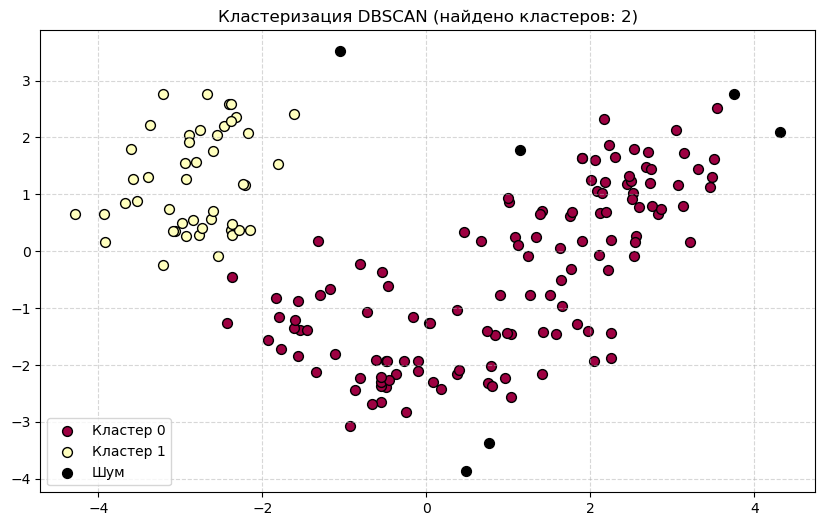

In [ ]:
# Теперь выполните кластеризацию и подберите оптимальные параметры
# Визуализируйте датасет
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.76, min_samples=5)
db_clusters = dbscan.fit_predict(X_pca)

plt.figure(figsize=(10, 6))

unique_labels = set(db_clusters)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]
        label_name = 'Шум'
    else:
        label_name = f'Кластер {k}'

    class_member_mask = (db_clusters == k)
    xy = X_pca[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], edgecolors='k', s=50, label=label_name)

plt.title(f'Кластеризация DBSCAN (найдено кластеров: {len(unique_labels) - (1 if -1 in db_clusters else 0)})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()